In [160]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [161]:
transform = transforms.ToTensor()  # convertendo o tipo da imagem para tensor

trainset = datasets.MNIST('./MNIST_data/', download=True, train=True, transform=transform)  # Carrega a parte de treino do dataset
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)  # Cria um buffer para pegar os dados por partes

valset = datasets.MNIST('./MNIST_data/', download=True, train=False, transform=transform)  # Carrega a parte de validação do dataset
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)  # Cria um buffer para pegar os dados por partes

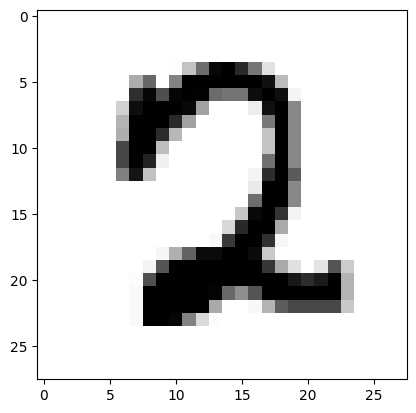

In [162]:
dataiter = iter(trainloader)
imagens, etiquetas = next(dataiter)
plt.imshow(imagens[0].numpy().squeeze(), cmap='gray_r')
plt.show()

In [163]:
print(imagens[0].shape) #verificar as dimensoes do tensaor da imagem
print(etiquetas[0].shape)#verificar as dimensoes do tensaor da etiqueta

torch.Size([1, 28, 28])
torch.Size([])


In [164]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.linear1 = nn.Linear(28*28, 128)  # camada de entrada, 784 neurônios que se ligam a 128
        self.linear2 = nn.Linear(128, 64)     # camada interna 1, 128 neurônios que se ligam a 64
        self.linear3 = nn.Linear(64, 10)      # camada interna 2, 64 neurônios que se ligam a 10

    def forward(self, X):
        X = F.relu(self.linear1(X))  # função de ativação da camada de entrada
        X = F.relu(self.linear2(X))  # função de ativação da camada interna 1 para a camada interna 2
        X = self.linear3(X)          # função de ativação da camada interna 2 para a camada de saída
        return F.log_softmax(X, dim=1)  # dados para calcular perda

In [165]:
def treino(modelo, trainloader, device):
  otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5)
  inicio = time()

  criterio = nn.NLLLoss()
  EPOCHS = 30
  modelo.train()

  for epoch in range(EPOCHS):
    perda_acumulada = 0.0

    for imagens, etiquetas in trainloader:
      imagens = imagens.view(imagens.shape[0], -1) #conversão das imagenss de entradas para vetores de 28x28
      otimizador.zero_grad() #zera o oimizador por conta do cilco anterior

      output = modelo(imagens.to(device)) #insere os dados no modelo
      perda_instantanea = criterio(output, etiquetas.to(device)) #calcula a perda da epoca atual
      perda_instantanea.backward()
      otimizador.step() #atualzia os pesos e bias

      perda_acumulada += perda_instantanea #incrementa a perda cumulada com cada perda das epocas




In [166]:
def validacao(modelo, valloader, device):
  conta_corretas, conta_todas = 0, 0

  for imagens,etiquetas in valloader:
    for i in range(len(etiquetas)):
      img = imagens[i].view(1, 784)

      with torch.no_grad():
        logps = modelo(img.to(device)) #output do modelo na escala logaritmica

      ps = torch.exp(logps)
      probab = list(ps.cpu().numpy()[0])
      etiqueta_pred = probab.index(max(probab))
      etiqueta_certa = etiquetas.numpy()[i]
      if(etiqueta_certa == etiqueta_pred): #compara o valor eocnotrado pela rede coma  etiqueta
        conta_corretas += 1
      conta_todas += 1

  print("Total de imagens testadas =", conta_todas)
  print("Total de imagens corretas =", conta_corretas)



In [167]:
modelo = Modelo()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo.to(device)

treino(modelo, trainloader, device)
validacao(modelo, valloader, device)



Total de imagens testadas = 10000
Total de imagens corretas = 9750
